In [1]:
import sys
sys.path.insert(0, '..')
import numpy as np 
import matplotlib.pyplot as plt
from qutip import Qobj, basis, mesolve, sigmax, sigmaz, sigmay, expect, Result, Options, tensor,qeye
from math import *
from oc_simulation.optimizer import Optimizer
from oc_simulation.simulation import OCSimulation


In [2]:
omega=2*np.pi*10e3
Detunings=[-omega/3,omega/2]
Amplitudes=[1,1]

test=Optimizer(T=5/omega,dt=0.05/omega,omega=omega,Points=3,Detuning=Detunings,Amplitude=Amplitudes)
time,result=test.run()


In [3]:
print(result.termination_reason,result.fid_err)
print(len([A[0] for A in result.final_amps]))
print(len(time))
print(5/omega)

Goal achieved 0.004649590147327798
100
100
7.957747154594768e-05


<function matplotlib.pyplot.show(close=None, block=None)>

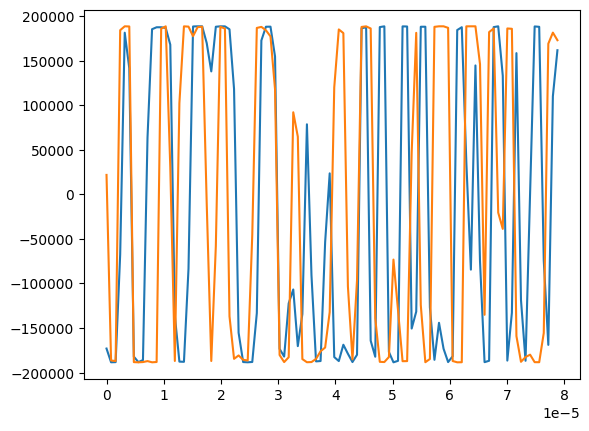

In [4]:
plt.plot(time,np.array([A[0] for A in result.final_amps],dtype=np.float64))
plt.plot(time,np.array([A[1] for A in result.final_amps],dtype=np.float64))
plt.show

c:\Users\Sami\Project\RAP\venv\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


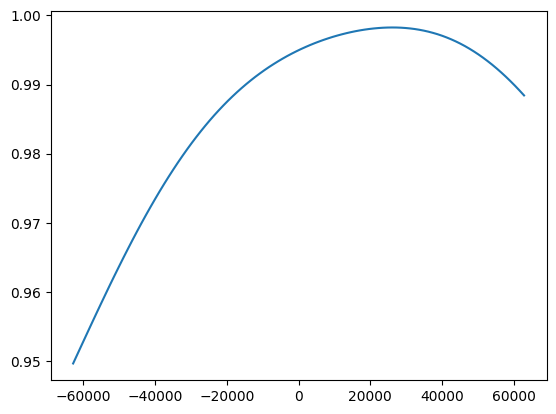

In [5]:
p=100
final=[]
Detunings=np.linspace(-omega,omega,p)
for d in Detunings:
    sim=OCSimulation(T=5/omega,dt=0.05/omega,Omega=omega,Times=time,Amps=result.final_amps,Detuning=d,Offset=1)
    output=sim.run()
    final.append(output[1][-1])
plt.plot(Detunings,final)
plt.show()
